# MINE 4201 - Laboratorio 2: Filtrado por Contenido y Estrategias de Embedding

En este laboratorio exploraremos los sistemas de recomendación basados en contenido, utilizando diferentes estrategias de representación vectorial (embeddings) para describir los ítems:

1. **TF-IDF** (Term Frequency – Inverse Document Frequency)
2. **Word2Vec** (Representaciones densas aprendidas)

Al finalizar, el estudiante será capaz de:
- Construir una matriz documento-término y calcular TF-IDF
- Aplicar selección de características para mejorar la representación
- Entrenar y evaluar un modelo de clasificación para recomendación por contenido
- Comprender el modelo Word2Vec y sus arquitecturas (Skip-gram, CBOW)
- Comparar las representaciones TF-IDF vs Word2Vec para filtrado por contenido
- Reflexionar sobre cómo estas estrategias de embedding se conectan con el Filtrado Colaborativo

---
## Contexto: Filtrado por Contenido vs Filtrado Colaborativo

En los sistemas de recomendación existen dos grandes familias de enfoques:

| Enfoque | Descripción | Datos que utiliza |
|---|---|---|
| **Filtrado por Contenido** | Recomienda ítems similares a los que el usuario ha preferido, basándose en las **características del ítem** (género, descripción, conceptos). | Atributos / features de los ítems |
| **Filtrado Colaborativo** | Recomienda ítems que usuarios similares han preferido, sin necesitar características del ítem. | Matriz de interacciones usuario-ítem |

### ¿Dónde entran los Embeddings?

Las estrategias de embedding (TF-IDF, Word2Vec, etc.) pueden utilizarse en **ambos** enfoques:

- **En filtrado por contenido:** se usan para representar las características de los ítems en un espacio vectorial continuo. Es lo que haremos en la primera parte de este laboratorio.
- **En filtrado colaborativo:** los embeddings pueden representar usuarios e ítems en un espacio latente compartido (e.g., factorización de matrices, embeddings neurales). Modelos como Word2Vec han inspirado técnicas como **Item2Vec**, donde se trata la secuencia de ítems consumidos por un usuario como una "oración" y se aprenden embeddings de ítems.

En este laboratorio nos centraremos en el **filtrado por contenido** usando TF-IDF y exploraremos Word2Vec como estrategia alternativa de representación.


Los sistemas de recomendación basados en contenido filtran contenido basado en la representación de items y el perfil del usuario. En este laboratorio trabajaremos con un conjunto de datos del sitio web [LibraryThing](https://https://www.librarything.com/).


## Preparación del entorno
Instale las librerias que vamos a utilizar e importelas en el ambiente de ejecución

In [1]:
!pip install scikit-learn
!pip install pandas
!pip install seaborn

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support



## Carga de archivos

Copie el archivo del dataset en el entorno colab en la pestaña files (la carpeta en el menú de la izquierda), carguemos el csv en un dataframe de pandas y revisemos su contenido.

In [3]:
if not os.path.exists('DB-BOOK-content.csv') :
  raise ValueError('El archivo DB-BOOK-content.csv no fue encontrado en el path')
else:
  print("Los archivos han sido cargados")

Los archivos han sido cargados


In [4]:
df_dbbook=pd.read_csv('DB-BOOK-content.csv', sep=';')
df_dbbook

,DBbook_userID,name,DBbook_ItemID,featureID,featureShortname,rate
0,1,"Contingency, Irony, and Solidarity",508,1066,/Category:1989_books,5
1,1,"Contingency, Irony, and Solidarity",508,2300,/Richard_Rorty,5
2,1,"Contingency, Irony, and Solidarity",508,2301,/Category:Works_about_Marcel_Proust,5
3,1,"Contingency, Irony, and Solidarity",508,2302,/Category:Books_by_Richard_Rorty,5
4,1,"Contingency, Irony, and Solidarity",508,2303,/Category:Books_about_irony,5
...,...,...,...,...,...,...
1439449,7255,The Catcher in the Rye,8010,3322,/Category:American_bildungsromans,3
1439450,7255,The Catcher in the Rye,8010,6746,/Category:1949_in_fiction,3
1439451,7255,The Catcher in the Rye,8010,9011,/J._D._Salinger,3
1439452,7255,The Catcher in the Rye,8010,10155,/Category:Novels_by_J._D._Salinger,3


Este dataset tiene un formato similar al que manejamos el taller pasado. Tiene una columna con el id del usuario, otra con el id del item y un rating.

Cada rating esta presente varias veces, una por cada característica de los libros, revisemos por ejemplo las características del libro con ID 8010.

Se selecciona del dataframe las columnas name, featureID y featureShortname, la instruccion drop_duplicates nos deja solamente las columnas que no

Nota: Para saber más de indexación de dataframes de pandas utilizando .loc hay una explicación en la [documentación](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)



In [5]:
df_dbbook.loc[df_dbbook.DBbook_ItemID==8010,['DBbook_ItemID','name','featureID','featureShortname']].drop_duplicates()

,DBbook_ItemID,name,featureID,featureShortname
996,8010,The Catcher in the Rye,3,/Communication100033020
997,8010,The Catcher in the Rye,4,/Fiction106367107
998,8010,The Catcher in the Rye,5,/LiteraryComposition106364329
999,8010,The Catcher in the Rye,6,/Writing106362953
1000,8010,The Catcher in the Rye,7,/WrittenCommunication106349220
1001,8010,The Catcher in the Rye,11,/Novel106367879
1002,8010,The Catcher in the Rye,13,/Abstraction100002137
1003,8010,The Catcher in the Rye,228,/DebutNovels
1004,8010,The Catcher in the Rye,233,/Category:Debut_novels
1005,8010,The Catcher in the Rye,277,"/Category:Little,_Brown_and_Company_books"


Cada libro tiene features que fueron extraidos de [DBpedia](https://wiki.dbpedia.org/). Dbpedia es una iniciativa para construir una representación de conceptos y relaciones mediante ontologías utilizando la información depositada en wikipedia. Más adelante vamos a utilizar DBPedia para otros talleres que aprovechan la información de la ontología de DBPedia, por ahora lo que tenemos es una representación de conjunto de palabras (o conceptos) para describir un item.  

## Creación de matriz documento-termino

En las siguientes líneas vamos a crear la matriz documento término, el primer paso es obtener en un dataframe los libros, los conceptos, y  los conceptos únicos por libro.

In [6]:
df_libros=df_dbbook.loc[:,['DBbook_ItemID','name']].drop_duplicates()
df_libros

,DBbook_ItemID,name
0,508,"Contingency, Irony, and Solidarity"
8,802,The Solitaire Mystery
26,889,Wise Blood
49,1367,The Bell Jar
72,1736,The Structure of Scientific Revolutions
...,...,...
1434966,2860,Practical Magic
1436627,3838,Destiny: A Chronicle of Deaths Foretold
1437751,5779,The Road to Omaha
1438719,3485,Kamikaze Girls


In [7]:
df_conceptos=df_dbbook.loc[:,['featureID','featureShortname']].drop_duplicates()
df_conceptos

,featureID,featureShortname
0,1066,/Category:1989_books
1,2300,/Richard_Rorty
2,2301,/Category:Works_about_Marcel_Proust
3,2302,/Category:Books_by_Richard_Rorty
4,2303,/Category:Books_about_irony
...,...,...
1438749,8790,/Category:Adventure_comedy_films
1438750,8791,/Category:Fantasy-comedy_films
1438752,8793,/Category:2004_Japanese_films
1438766,9393,/NovelsByDavidDrake


In [8]:
df_libros_concepto=df_dbbook.loc[:,['DBbook_ItemID','name','featureID','featureShortname']].drop_duplicates()
df_libros_concepto

,DBbook_ItemID,name,featureID,featureShortname
0,508,"Contingency, Irony, and Solidarity",1066,/Category:1989_books
1,508,"Contingency, Irony, and Solidarity",2300,/Richard_Rorty
2,508,"Contingency, Irony, and Solidarity",2301,/Category:Works_about_Marcel_Proust
3,508,"Contingency, Irony, and Solidarity",2302,/Category:Books_by_Richard_Rorty
4,508,"Contingency, Irony, and Solidarity",2303,/Category:Books_about_irony
...,...,...,...,...
1438763,3963,Queen of Demons,790,/1998Novels
1438764,3963,Queen of Demons,793,/Category:1998_novels
1438765,3963,Queen of Demons,4006,/David_Drake
1438766,3963,Queen of Demons,9393,/NovelsByDavidDrake


Se quiere obtener una martiz que tenga como filas cada uno de los libros, y como columnas cada uno de los conceptos, y en cada coordenada un 1 si esta presente el concepto y 0 de lo contrario. A esta operación se le conoce como pivot de una tabla.

La función [pivot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html) toma tres parámetros: la columna del dataframe original que va a tomar el índice de las filas del nuevo dataframe (index), la columna del dataframe original mediante la cual se van a generar las columnas (columns) y values los valores con los cuales se va a llenar el dataframe, en este caso  vamos a dejar momentaneamente el id del feature para indicar que existe.

Finalmente aplicamos la función [notna](https://pandas.pydata.org/docs/reference/api/pandas.notna.html) para modificar uno a uno los elementos de la matriz



In [9]:

df_matriz_libros_concepto = (
    df_libros_concepto[['DBbook_ItemID', 'featureID']]
      .drop_duplicates()
      .pivot(index='DBbook_ItemID', columns='featureID', values='featureID')
      .notna()              # vectorized (fast)
      .astype('int8')       # 1/0 in int8
)

In [10]:
df_matriz_libros_concepto

featureID,1,2,3,4,5,6,7,8,9,10,...,13992,13993,13994,13995,13996,13997,13998,13999,14000,14001
DBbook_ItemID,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8164,0,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8166,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8167,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df_matriz_libros_concepto.shape

(6164, 12246)

En la siguiente celda se está aplicando la función [sumatoria](https://www.geeksforgeeks.org/python-pandas-dataframe-sum/) por eje al dataframe anterior, por defecto el eje es 0, por lo que generará una Serie (vector) del tamaño de las columnas y por cada columna calculará la sumatoria

In [12]:
help(pd.DataFrame.sum)

Help on function sum in module pandas.core.generic:

sum(self, axis: 'Axis | None' = None, skipna: 'bool_t' = True, numeric_only: 'bool_t' = False, min_count: 'int' = 0, **kwargs)
    Return the sum of the values over the requested axis.
    
    This is equivalent to the method ``numpy.sum``.
    
    Parameters
    ----------
    axis : {index (0), columns (1)}
        Axis for the function to be applied on.
        For `Series` this parameter is unused and defaults to 0.
    
        For DataFrames, specifying ``axis=None`` will apply the aggregation
        across both axes.
    
        .. versionadded:: 2.0.0
    
    skipna : bool, default True
        Exclude NA/null values when computing the result.
    numeric_only : bool, default False
        Include only float, int, boolean columns. Not implemented for Series.
    
    min_count : int, default 0
        The required number of valid values to perform the operation. If fewer than
        ``min_count`` non-NA values are prese

In [13]:
series_suma=df_matriz_libros_concepto.sum()
series_suma

featureID
1           6
2         225
3        2766
4        2672
5        2674
         ... 
13997       1
13998       1
13999       1
14000       1
14001       1
Length: 12246, dtype: int64

El objeto series_suma no es un dataframe sino un objeto tipo Series, que es un arreglo. Un dataframe puede ser visto como una concatenación de varios objetos de tipo Series

In [14]:
type(series_suma)

pandas.core.series.Series

**Interprete las siguientes figuras y diga qué quieren decir en términos del número de items y de características asignadas a los items**

<Axes: ylabel='None'>

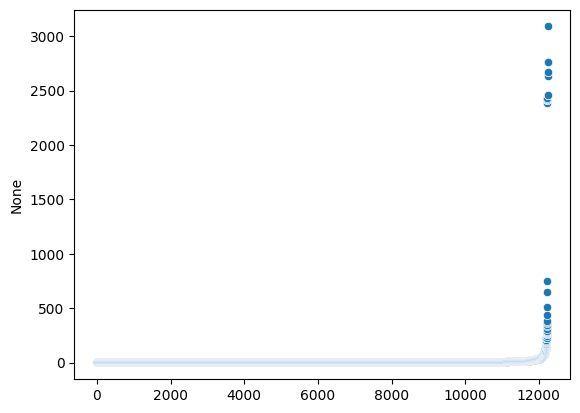

In [15]:
sns.scatterplot(x=range(0,len(series_suma)) ,y=series_suma.sort_values() )

In [16]:
series_suma_2=df_matriz_libros_concepto.sum(axis=1)
series_suma_2

DBbook_ItemID
1       23
2       20
3       36
5       23
7       22
        ..
8164    23
8166    13
8167    17
8168    22
8169    25
Length: 6164, dtype: int64

<Axes: ylabel='None'>

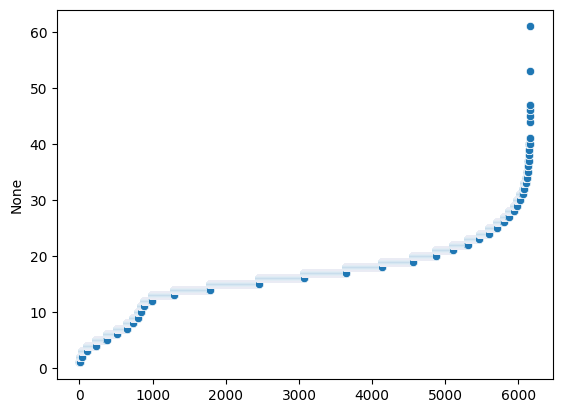

In [17]:
sns.scatterplot(x=range(0, len(series_suma_2)), y=series_suma_2.sort_values())

# Cálculo de matriz tf-idf

La matriz df_matriz_libros_concepto hasta el momento tiene en cada coordenada la presencia o ausencia de la característica que describe el atributo, este sería el término $\text{tf}$ de la siguiente fórmula donde $i$ es un término o palabra y $d$ es un documento.

$\text{tfidf}_{i,d} = \text{tf}_{i,d} \cdot \text{idf}_{i}$

El Inverse Document Frequency esta definido como:

$\text{idf}_{i,d} = \log \frac{N}{\text{df}_{i}}$

Donde $\text{df}_{t}$ es el número de documentos en los que aparece el término $i$ y N el número total de documentos



En python es posible operar vectores con escalares directamente, gracias a que por debajo python genera operaciones entre arreglos cuando operamos con un escalar mediante la operación de [broadcasting](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html) Por ejemplo, el anterior arreglo se puede dividir entre 6, por debajo python genera un arreglo del mismo tamaño y realiza la operación elemento a elemento

In [18]:
series_suma/6

featureID
1          1.000000
2         37.500000
3        461.000000
4        445.333333
5        445.666667
            ...    
13997      0.166667
13998      0.166667
13999      0.166667
14000      0.166667
14001      0.166667
Length: 12246, dtype: float64

En las siguientes celdas, cree un objeto tipo series llamado df_idf, que contiene el IDF de cada atributo. Puede utilizar la función [np.log2](https://docs.scipy.org/doc/numpy/reference/generated/numpy.log2.html) de numpy

In [19]:
N = df_matriz_libros_concepto.shape[0]  # Número total de documentos (libros)
df_idf = np.log2(N / series_suma)
df_idf

featureID
1        10.004689
2         4.775870
3         1.156066
4         1.205947
5         1.204867
           ...    
13997    12.589651
13998    12.589651
13999    12.589651
14000    12.589651
14001    12.589651
Length: 12246, dtype: float64

Si df_idf fue calculado correctamente, la siguiente instrucción multiplicará cada fila del dataframe elemento por elemento (element-wise) por la serie que contiene el IDF

In [20]:
df_matriz_tf_idf=df_matriz_libros_concepto.multiply(df_idf, axis=1)
df_matriz_tf_idf

featureID,1,2,3,4,5,6,7,8,9,10,...,13992,13993,13994,13995,13996,13997,13998,13999,14000,14001
DBbook_ItemID,,,,,,,,,,,,,,,,,,,,,
1,10.004689,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,6.808291,7.035062,9.589651,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,10.004689,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,7.035062,9.589651,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,6.808291,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
7,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8164,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
8166,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
8167,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


En el siguiente mapa de calor se observa el tf_idf de los items representados en las 300 características con mayor frecuencia.

In [21]:
df_matriz_tf_idf.loc[:,series_suma.nlargest(300).index]

featureID,13,3,6,7,5,4,11,65,59,60,...,1637,2214,2227,2228,2230,2702,447,496,1299,1507
DBbook_ItemID,,,,,,,,,,,,,,,,,,,,,
1,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8164,0.996727,1.156066,1.158676,1.158676,1.204867,1.205947,1.227159,0.000000,0.000000,0.000000,...,7.589651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.325209,1.325795,1.325795,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.325209,1.325795,1.325795,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='featureID', ylabel='DBbook_ItemID'>

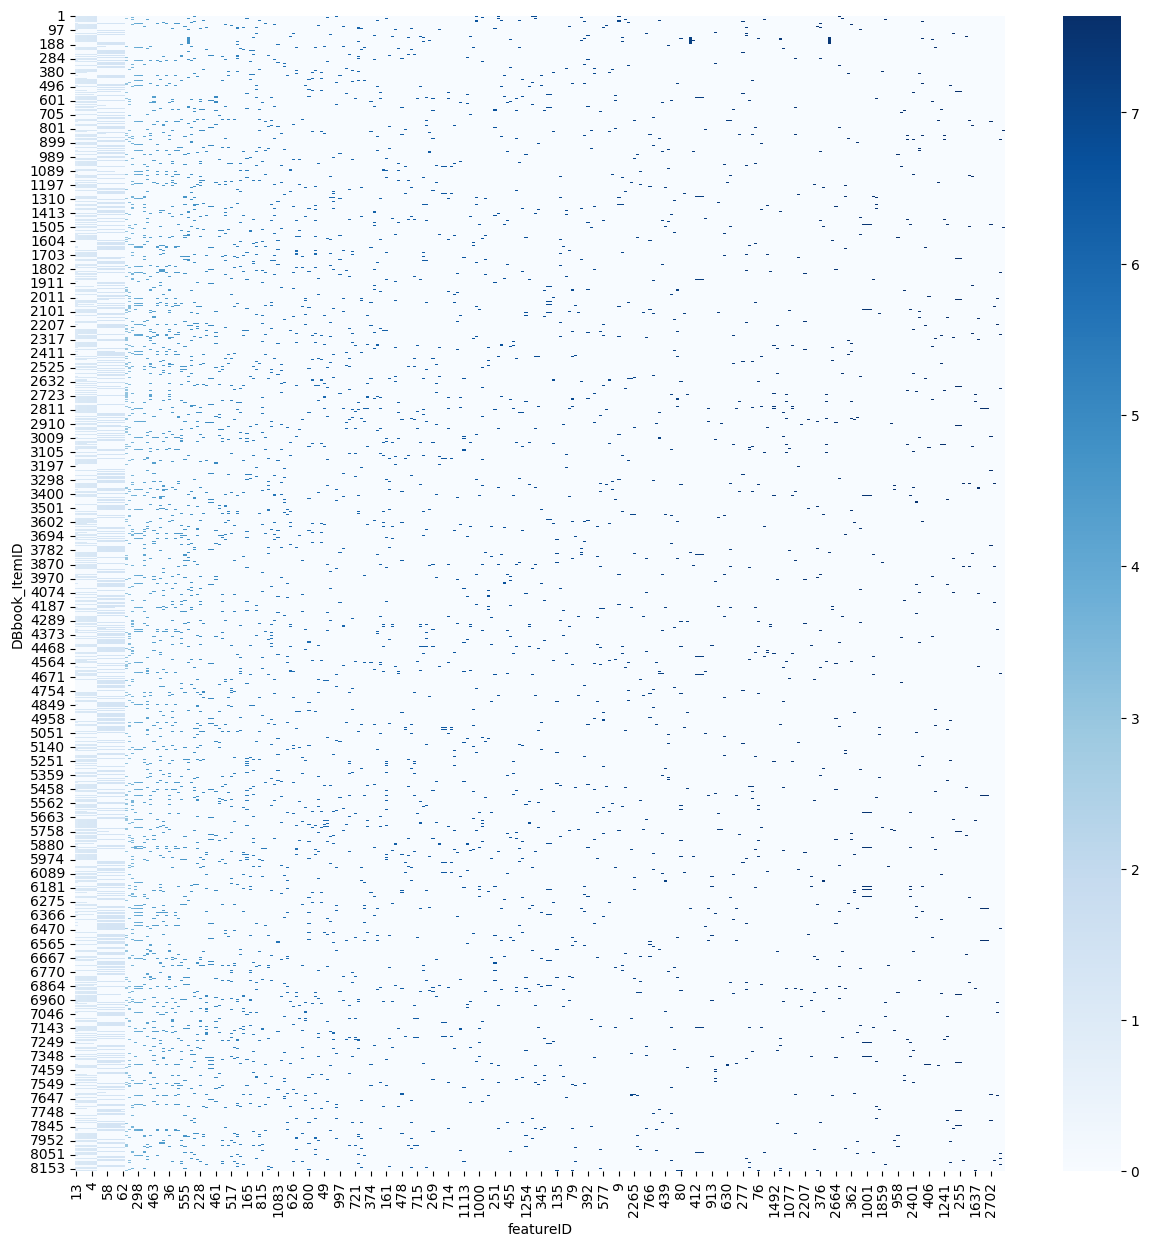

In [22]:
plt.rcParams["figure.figsize"] = (15,15)
sns.heatmap(df_matriz_tf_idf.loc[:,series_suma.nlargest(300).index],cmap="Blues", vmin=0)

**¿Qué puede interpretar sobre la figura anterior?
Encuentre los nombres de las características más frecuentes**

# Selección de características

Una vez realizado el proceso de indexamiento, se puede realizar el proceso de selección de características.

En este momento contamos con más de 12 mil conceptos. ¿Con cuántos vale la pena crear los modelos de filtrado?

El paso más simple es filtrar las características con baja frecuencia dentro del dataset

In [23]:
series_suma.describe()

count    12246.000000
mean         8.394823
std         95.183540
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       3089.000000
dtype: float64

**¿Qué puede decir sobre la distribución de frecuencia de las características en los items? ¿Vale la pena tener todas las características que tenemos actualmente?**

.
**Retire de la matriz df_matrix_tf_idf las columnas que representan a los items que tienen menos de 3 items asociados**

In [24]:
# Se filtra la serie por aquellos que tienen al menos 3
series_suma[series_suma>=3]

featureID
1           6
2         225
3        2766
4        2672
5        2674
         ... 
13204       5
13549       3
13627       3
13920       5
13922       5
Length: 3894, dtype: int64

In [25]:
# Filtramos dejando solo las características que aparecen en al menos 3 libros
columnas_filtradas = series_suma[series_suma >= 3].index
df_matriz_tf_idf = df_matriz_tf_idf[columnas_filtradas]

In [26]:
df_matriz_tf_idf

featureID,1,2,3,4,5,6,7,8,9,10,...,12919,12995,12997,13045,13046,13204,13549,13627,13920,13922
DBbook_ItemID,,,,,,,,,,,,,,,,,,,,,
1,10.004689,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,6.808291,7.035062,9.589651,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.004689,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,7.035062,9.589651,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,6.808291,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8164,0.000000,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8166,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8167,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Para las siguientes estrategias de selección de características, tenemos que aplicar técnicas supervisadas (que conocen la clase a predecir o lo que se quiere pronosticar), para esto tenemos que retomar nuestro dataset original de interacciones entre usuarios e items para asignar la etiqueta (le gustó/ no le gustó)

In [27]:
# Recordemos como es el dataset original.
df_dbbook.head(20)

,DBbook_userID,name,DBbook_ItemID,featureID,featureShortname,rate
0,1,"Contingency, Irony, and Solidarity",508,1066,/Category:1989_books,5
1,1,"Contingency, Irony, and Solidarity",508,2300,/Richard_Rorty,5
2,1,"Contingency, Irony, and Solidarity",508,2301,/Category:Works_about_Marcel_Proust,5
3,1,"Contingency, Irony, and Solidarity",508,2302,/Category:Books_by_Richard_Rorty,5
4,1,"Contingency, Irony, and Solidarity",508,2303,/Category:Books_about_irony,5
5,1,"Contingency, Irony, and Solidarity",508,2304,/Category:Cambridge_University_Press_books,5
6,1,"Contingency, Irony, and Solidarity",508,2305,/Category:Cognitive_science_literature,5
7,1,"Contingency, Irony, and Solidarity",508,2306,/Category:Ethics_books,5
8,1,The Solitaire Mystery,802,3,/Communication100033020,4
9,1,The Solitaire Mystery,802,4,/Fiction106367107,4


Creemos un dataframe para crear un dataset de un sistema de recomendación como el visto en el laboratorio pasado (una única interacción de tipo usuario, item y rating)

In [28]:
df_all_interactions=df_dbbook[['DBbook_userID','DBbook_ItemID','rate']].drop_duplicates()
df_all_interactions

,DBbook_userID,DBbook_ItemID,rate
0,1,508,5
8,1,802,4
26,1,889,5
49,1,1367,5
72,1,1736,5
...,...,...,...
1439370,7255,6871,3
1439392,7255,7227,3
1439401,7255,7471,3
1439416,7255,7472,4


Para asignar una clase, se binarizan los ratings. Una regla simple es calcular el rating promedio por persona. Todo lo que esté por debajo del promedio se clasifica como no le gusta, igual o por encima es si le gusta.

In [29]:
df_user_mean=df_all_interactions.groupby('DBbook_userID')['rate'].mean().reset_index()
df_user_mean.columns=['DBbook_userID','mean']
df_user_mean

,DBbook_userID,mean
0,1,4.545455
1,2,4.250000
2,3,3.684211
3,4,3.571429
4,5,4.181818
...,...,...
6176,7251,3.800000
6177,7252,3.230769
6178,7253,4.000000
6179,7254,4.222222


**Realice un merge entre df_all_interactions y df_user_mean, asignando su resultado a df_all_interactions.
Cree una nueva columna en el dataframe df_all_interactions llamada 'class' con True si el rating del usuario es mayor o igual a su promedio**

[Documentación pandas merge](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)

[Tutorial creación de columnas a partir del valor de otras](https://thispointer.com/python-pandas-how-to-add-new-columns-in-a-dataframe-using-or-dataframe-assign/)

In [30]:
df_all_interactions = df_all_interactions.merge(df_user_mean, on='DBbook_userID')

In [31]:
df_all_interactions['class'] = df_all_interactions['rate'] >= df_all_interactions['mean']

In [32]:
df_all_interactions

,DBbook_userID,DBbook_ItemID,rate,mean,class
0,1,508,5,4.545455,True
1,1,802,4,4.545455,False
2,1,889,5,4.545455,True
3,1,1367,5,4.545455,True
4,1,1736,5,4.545455,True
...,...,...,...,...,...
75537,7255,6871,3,3.166667,False
75538,7255,7227,3,3.166667,False
75539,7255,7471,3,3.166667,False
75540,7255,7472,4,3.166667,True


Por último, se procede a partir el dataset en entrenamiento y test. Se utiliza de la librería sklearn la función [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

Esta recibe como parámetro el dataset a partir, el porcentaje para test y un parámetro que indica la variable por la cual estratificar la partición, en este caso quisieramos que las interacciones en test sean de usuarios que vimos en train, por lo tanto se deja estratificado por usuario.

In [33]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.
    
    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.
    
    Read more in the :ref:`User Guide <cross_validation>`.
    
    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.
    
    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to

In [34]:
#Para garantizar reproducibilidad en resultados
seed = 10
random.seed(seed)
np.random.seed(seed)
df_all_interactions_train, df_all_interactions_test =train_test_split(df_all_interactions, test_size=0.2, stratify=df_all_interactions['DBbook_userID'])

In [35]:
df_all_interactions_train

,DBbook_userID,DBbook_ItemID,rate,mean,class
8703,840,2815,4,4.111111,False
64432,6179,4425,3,2.785714,True
73313,7034,6978,5,4.187500,True
22020,2105,2742,4,3.529412,True
31264,2998,7171,3,3.550000,False
...,...,...,...,...,...
31712,3035,7494,5,4.250000,True
31592,3026,2094,3,3.285714,False
65130,6246,6288,4,4.200000,False
5437,518,4434,5,4.250000,True


In [36]:
df_all_interactions_test

,DBbook_userID,DBbook_ItemID,rate,mean,class
29332,2817,1971,3,3.600000,False
65989,6333,4048,3,3.125000,False
66883,6417,6988,3,4.111111,False
28307,2708,4854,5,4.333333,True
45446,4370,7538,3,3.666667,False
...,...,...,...,...,...
53549,5145,1249,3,4.230769,False
63091,6058,2957,5,4.250000,True
34956,3341,1934,3,3.200000,False
73467,7048,3812,3,4.750000,False


In [37]:
df_all_interactions_train.DBbook_userID.value_counts()

DBbook_userID
1728    19
643     19
2643    19
509     19
2891    19
        ..
2484     4
5984     4
4159     4
4698     4
5463     4
Name: count, Length: 6181, dtype: int64

In [38]:
df_all_interactions_test.DBbook_userID.value_counts()

DBbook_userID
1955    5
2840    5
3395    5
921     5
1537    5
       ..
5511    1
3512    1
7129    1
1894    1
3341    1
Name: count, Length: 6181, dtype: int64

In [39]:
df_conteos_usuario_train_test=pd.concat([df_all_interactions_train.DBbook_userID.value_counts(),df_all_interactions_test.DBbook_userID.value_counts()],axis=1)
df_conteos_usuario_train_test.columns=['train_count','test_count']

In [40]:
df_conteos_usuario_train_test

,train_count,test_count
DBbook_userID,,
1728,19,5
643,19,5
2643,19,5
509,19,5
2891,19,5
...,...,...
2484,4,1
5984,4,1
4159,4,1


In [41]:
df_conteos_usuario_train_test.nlargest(500,'test_count')

,train_count,test_count
DBbook_userID,,
1728,19,5
643,19,5
2643,19,5
509,19,5
2891,19,5
...,...,...
5918,18,4
7188,18,4
3461,18,4


**Chi-cuadrado**

La selección de características mediante la prueba [chi-cuadrado](https://en.wikipedia.org/wiki/Chi-squared_test) nos dice si la diferencia observada entre las frecuencias de co-ocurrencia de dos variables es significativa. La idea es seleccionar características que más ayuden a discriminar la clase objetivo observando la frecuencia en la que ocurren juntas.

La librería sklearn permite identificar la importancia de cada una de las variables utilizando el método [chi2](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html)

In [42]:
help(chi2)

Help on function chi2 in module sklearn.feature_selection._univariate_selection:

chi2(X, y)
    Compute chi-squared stats between each non-negative feature and class.
    
    This score can be used to select the `n_features` features with the
    highest values for the test chi-squared statistic from X, which must
    contain only **non-negative integer feature values** such as booleans or frequencies
    (e.g., term counts in document classification), relative to the classes.
    
    If some of your features are continuous, you need to bin them, for
    example by using :class:`~sklearn.preprocessing.KBinsDiscretizer`.
    
    Recall that the chi-square test measures dependence between stochastic
    variables, so using this function "weeds out" the features that are the
    most likely to be independent of class and therefore irrelevant for
    classification.
    
    Read more in the :ref:`User Guide <univariate_feature_selection>`.
    
    Parameters
    ----------
    X : {a

En filtrado por contenido, se arma un modelo por usuario. Por ahora vamos a escoger las características más importantes para el primer usuario del dataset de test

In [43]:
#Debería dar 2817
primer_usuario_id=df_all_interactions_test.iloc[0]['DBbook_userID']
primer_usuario_id

2817

Obtengamos los ids de los items con los que ha interactuado y su opinion

In [44]:
df_temporal_usuario=df_all_interactions_train.loc[df_all_interactions_train.DBbook_userID==1124,['DBbook_ItemID','class']]
df_temporal_usuario

,DBbook_ItemID,class
11947,5736,True
11944,4108,False
11943,4103,True
11938,1391,False
11937,1292,False
11940,1970,True
11946,4799,False
11941,3006,True
11939,1578,True


Peguemos a este dataframe la representación vectorial de tf_idf por el id del item, en la matriz es el índice de las filas

In [45]:
df_temporal_usuario=df_temporal_usuario.merge(df_matriz_tf_idf, how='left', left_on='DBbook_ItemID', right_index=True)
df_temporal_usuario

,DBbook_ItemID,class,1,2,3,4,5,6,7,8,...,12919,12995,12997,13045,13046,13204,13549,13627,13920,13922
11947,5736,True,0.0,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11944,4108,False,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11943,4103,True,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11938,1391,False,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11937,1292,False,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11940,1970,True,0.0,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11946,4799,False,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11941,3006,True,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11939,1578,True,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Este dataframe representa los datos de entrenamiento del modelo para predicción de una clase binaria (class True es le gusta, class False es no le gusta)

In [46]:
#vamos a indexar solamente las columnas que son características, la prueba chi2 lo compara todas las características contra la clase objetivo
features=df_matriz_tf_idf.columns

In [47]:
pesos_chi2, pval= chi2(df_temporal_usuario[features],df_temporal_usuario['class'])

In [48]:
#La prueba puede arrojar nan
pesos_chi2

array([       nan, 3.82069596, 1.84970513, ...,        nan,        nan,
              nan])

In [49]:
pval

array([       nan, 0.05062321, 0.17381769, ...,        nan,        nan,
              nan])

In [50]:
# LLenamos con peso 0 los que no se pudieron calcular
pesos_chi2=np.nan_to_num(pesos_chi2)
pesos_chi2

array([0.        , 3.82069596, 1.84970513, ..., 0.        , 0.        ,
       0.        ])

Se crea una máscara de indexación con los valores que son positivos según la prueba

In [51]:
pesos_chi2_mask=pesos_chi2>0

In [52]:
pesos_chi2_mask

array([False,  True,  True, ..., False, False, False])

In [53]:
features[pesos_chi2_mask]

Index([    2,     3,     4,     5,     6,     7,    11,    13,    22,    30,
          56,    58,    59,    60,    62,    63,    64,    65,    66,    67,
          86,    92,   116,   127,   132,   173,   186,   192,   196,   215,
         241,   242,   290,   292,   294,   295,   296,   297,   298,   372,
         374,   377,   398,   406,   432,   436,   437,   438,   439,   463,
         474,   478,   490,   499,   504,   523,   528,   555,   556,   579,
         582,   725,   778,   797,   801,  1077,  1289,  1301,  1415,  1731,
        1733,  1833,  1887,  1956,  2211,  2213,  2288,  2299,  3252,  3253,
        3753,  4367,  4368,  4602,  4605,  4606,  4723,  4860,  5057,  6095,
        6096,  6097,  6986,  8656,  8658,  8659, 10004],
      dtype='int64', name='featureID')

El siguiente sería el resultado, se recortaron las columnas de pesos del usuario, dejando 119 features.

In [54]:
df_temporal_usuario.loc[:,features[pesos_chi2_mask]]

featureID,2,3,4,5,6,7,11,13,22,30,...,4860,5057,6095,6096,6097,6986,8656,8658,8659,10004
11947,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,1.227159,0.996727,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.004689
11944,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.035062,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.589651,9.782296,9.782296,0.000000
11943,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10.004689,0.000000,0.000000,0.000000,0.000000
11938,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11937,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11940,4.77587,1.156066,1.205947,1.204867,1.158676,1.158676,1.227159,0.996727,7.460368,0.000000,...,0.000000,9.004689,11.004689,11.004689,11.004689,0.000000,0.000000,0.000000,0.000000,0.000000
11946,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11941,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996727,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11939,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.004689,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [55]:
del df_temporal_usuario

**Complete el código de la siguiente celda, el objetivo es crear un diccionario donde la llave es el id del usuario y el valor es un arreglo con los features seleccionados para el usuario**

El proceso que implementamos no esta optimizado, por lo que vamos a armar el modelo solamente para los 500 usuarios con más ratings en el dataset de test.


In [56]:
from sklearn.feature_selection import chi2
import numpy as np

diccionario_usuarios_features = {}

# 500 usuarios con más ratings en test
unique_users_test = df_conteos_usuario_train_test.nlargest(500, 'test_count').index

i = 0
print(unique_users_test.shape)

for user in unique_users_test:
  if user not in diccionario_usuarios_features:

    df_temporal_usuario = df_all_interactions_train.loc[
      df_all_interactions_train.DBbook_userID == user,
      ['DBbook_ItemID', 'class']
    ]


    df_temporal_usuario = df_temporal_usuario.merge(
      df_matriz_tf_idf,
      how='left',
      left_on='DBbook_ItemID',
      right_index=True
    )


    pesos_chi2, pval = chi2(df_temporal_usuario[features], df_temporal_usuario['class'])

    pesos_chi2 = np.nan_to_num(pesos_chi2)
    pesos_chi2_mask = pesos_chi2 > 0

    features_usuario = features[pesos_chi2_mask]
    diccionario_usuarios_features[user] = features_usuario

    i += 1
    if i % 50 == 0:
      print(i)

    del df_temporal_usuario

(500,)
50
100
150
200
250
300
350
400
450
500


In [57]:
len(diccionario_usuarios_features)

500

In [58]:
diccionario_usuarios_features.keys()

dict_keys([1728, 643, 2643, 509, 2891, 2678, 3602, 3639, 2812, 5137, 1783, 1512, 1549, 1114, 2610, 3703, 4542, 6123, 2539, 6988, 581, 118, 4466, 4628, 4562, 5338, 6880, 4124, 4192, 627, 681, 2757, 1660, 1690, 2877, 4926, 872, 3490, 6115, 6585, 2345, 4877, 5698, 664, 2107, 1343, 409, 2474, 6167, 7007, 774, 4714, 1609, 4232, 3119, 734, 3539, 2159, 248, 7215, 2881, 2914, 2172, 1176, 1214, 2258, 1715, 676, 5688, 6366, 254, 4277, 4619, 5569, 5591, 4185, 5951, 5186, 3879, 6556, 4764, 4984, 2682, 3484, 6873, 6562, 6487, 6134, 2852, 6694, 5995, 921, 6627, 107, 5905, 68, 6828, 3824, 430, 189, 2160, 1563, 158, 5931, 4234, 9, 23, 4701, 3342, 2288, 3219, 5486, 6387, 4627, 7248, 3322, 5261, 6432, 2313, 5017, 1955, 4242, 3852, 3799, 6335, 1722, 1084, 1021, 4622, 6084, 2490, 3957, 2230, 1247, 3921, 2137, 188, 4500, 6333, 5573, 1206, 2097, 2041, 4908, 2089, 2689, 6168, 689, 1541, 3348, 351, 3083, 4040, 6715, 938, 4469, 2185, 6219, 209, 4425, 4987, 5278, 6546, 1076, 3255, 2262, 321, 1019, 7068, 5727, 3

Otro criterio que puede ser usado es [Mutual Information](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn.feature_selection.mutual_info_classif)

# Modelo de recomendación y evaluación

Una vez seleccionadas las características por usuario, se puede usar el dataset de entrenamiento para aprender un modelo de clasificación binaria y probarlo sobre test.

Uno de los modelos que puede ser utilizado es el [clasificador por vecinos más cercanos](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm).

Cada usuario tiene unas instancias representadas en un espacio vectorial del tamaño de las características seleccionadas anteriormente. Para una nueva instancia (predicción) se mira cuáles son los k vecinos más cercanos a ese dato nuevo y se predice la clase mayoritaria dentro del grupo de los vecinos. Observe el siguiente ejemplo.

In [59]:
%%html
<iframe src="https://es.wikipedia.org/wiki/K_vecinos_m%C3%A1s_pr%C3%B3ximos#/media/Archivo:KnnClassification.svg" width="1200" height="600"></iframe>

Tomemos como ejemplo el usuario 3852, armemos su conjunto de entrenamiento. Note que se estan seleccionando solamente los features calculados en el punto anterior

In [60]:
usuario_id = 3852
if usuario_id not in diccionario_usuarios_features:
    usuario_id = next(iter(diccionario_usuarios_features))
    print(f"Usuario 3852 no disponible en entrenamiento. Se usa usuario {usuario_id}.")

features_usuario = diccionario_usuarios_features[usuario_id]
df_temporal_usuario_train = df_all_interactions_train.loc[
    df_all_interactions_train.DBbook_userID == usuario_id, ['DBbook_ItemID', 'class']
 ]
df_temporal_usuario_train = df_temporal_usuario_train.merge(
    df_matriz_tf_idf[features_usuario], how='left', left_on='DBbook_ItemID', right_index=True
)
df_temporal_usuario_train

,DBbook_ItemID,class,2,3,4,5,6,7,11,13,...,4045,4783,4913,5017,6186,6187,6318,7650,7651,8839
40213,7275,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,7.945795,11.004689,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40203,3537,True,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,1.227159,0.996727,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.004689
40201,2953,True,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40206,5683,False,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,1.227159,0.996727,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40208,6709,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,8.782296,0.000000,0.000000,8.267723,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40209,6842,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40205,5483,True,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
40197,2836,True,0.00000,1.156066,1.205947,1.204867,1.158676,1.158676,1.227159,0.996727,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.004689,10.589651,0.000000
40195,2069,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996727,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.004689,0.000000,0.000000,0.000000
40194,2007,True,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996727,...,0.000000,0.000000,0.000000,0.000000,10.589651,10.589651,0.000000,0.000000,0.000000,0.000000


Armamos de igual forma el conjunto de test

In [61]:
df_temporal_usuario_test = df_all_interactions_test.loc[
    df_all_interactions_test.DBbook_userID == usuario_id, ['DBbook_ItemID', 'class']
 ]
df_temporal_usuario_test = df_temporal_usuario_test.merge(
    df_matriz_tf_idf[features_usuario], how='left', left_on='DBbook_ItemID', right_index=True
)
df_temporal_usuario_test

,DBbook_ItemID,class,2,3,4,5,6,7,11,13,...,4045,4783,4913,5017,6186,6187,6318,7650,7651,8839
40196,2578,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,10.589651,10.589651,0.0,0.000000,0.0,0.0
40210,6965,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996727,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0
40200,2839,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,10.004689,0.0,0.0
40212,7271,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0
40204,4760,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0


Utilizaremos la clase [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) de scikit-learn para hacer la predicción de los datos del conjunto de test. El modelo tiene 3 métodos principales. El constructor permite inicializar el k a usar, la métrica entre otros; fit sirve para darle los datos de entrenamiento base al modelo; y predict para predecir los datos que se le pasan.

In [62]:
#Con esta configuración se utilizan los 3 vecinos más cercanos, con distancia euclidiana
knn_clasif=KNeighborsClassifier(3)

In [63]:
# Fit recibe la matriz de entrenamiento y la clase objetivo
knn_clasif.fit(df_temporal_usuario_train[features_usuario], df_temporal_usuario_train['class'])

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [64]:
# llamamos predict sobre  los test , creando una nueva columna en el dataframe de test
df_temporal_usuario_test['predict']=knn_clasif.predict(df_temporal_usuario_test[features_usuario])

In [65]:
df_temporal_usuario_test[['DBbook_ItemID','class','predict']].merge(df_libros, how='left', on='DBbook_ItemID')

,DBbook_ItemID,class,predict,name
0,2578,True,True,A Room with a View
1,6965,False,False,Desert of the Heart
2,2839,False,True,The Bone Doll's Twin
3,7271,False,False,Mr. Midshipman Hornblower
4,4760,False,False,Geography Club


**En las siguientes celdas realice hipótesis sobre por qué falló la clasificación para estos items y por qué funcionó para los otros, revise los conceptos seleccionados para el usuario y los asociados a los items**

La clasificación puede fallar cuando el item no comparte ningún concepto o comparte muy pocos de DBpedia, si el vector TF-IDF tiene casi todo en cero para los features que selecciona chi-cuadrado, el modelo no tiene información para encontrar vecinos.

La clasificación funciono mejor cuando el item del test comparte muchos conceptos ósea que es alto en TF-IDF, en este caso, el vector del item nuevo cae cerca de los vecinos en el espacio de features.

Finalmente, la librería sklearn tiene diferentes métricas de evaluación de clasificación. En particular podemos calcular la matriz de confusión de la clasificación utilizando la función [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), y el cálculo de las métricas precision, recall, y f1 con la función [precision_recall_fscore_support](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html)

In [66]:
tn, fp, fn, tp = confusion_matrix(df_temporal_usuario_test['class'],df_temporal_usuario_test['predict'], labels=[False,True]).ravel()

(tn, fp, fn, tp)

(3, 1, 0, 1)

In [67]:
precision_recall_fscore_support(df_temporal_usuario_test['class'],df_temporal_usuario_test['predict'], pos_label=True,average='binary')

(0.5, 1.0, 0.6666666666666666, None)

**Ejercicio: Realice las predicciones binarias para los usuarios en el conjunto de test a los que se les hizo la selección de características, mida la precisión, el recall y f_score de su modelo con las predicciones realizadas y ajústelo cambiando el k**

In [68]:
# =============================================================================
# PUNTO 2: Predicciones binarias para todos los usuarios con seleccion de
# caracteristicas, evaluacion de precision, recall y f-score, ajuste de K
# =============================================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import numpy as np
import pandas as pd

# Valores de K a probar
valores_k = [3, 5, 7, 9]

resultados_por_k = {}

for k in valores_k:
    lista_precision = []
    lista_recall = []
    lista_fscore = []
    usuarios_evaluados = 0

    for user in unique_users_test:
        if user not in diccionario_usuarios_features:
            continue

        features_usuario = diccionario_usuarios_features[user]

        if len(features_usuario) == 0:
            continue

        # Armar conjunto de entrenamiento del usuario
        df_train_user = df_all_interactions_train.loc[
            df_all_interactions_train.DBbook_userID == user, ['DBbook_ItemID', 'class']
        ].merge(
            df_matriz_tf_idf[features_usuario],
            how='left',
            left_on='DBbook_ItemID',
            right_index=True
        )

        # Armar conjunto de test del usuario
        df_test_user = df_all_interactions_test.loc[
            df_all_interactions_test.DBbook_userID == user, ['DBbook_ItemID', 'class']
        ].merge(
            df_matriz_tf_idf[features_usuario],
            how='left',
            left_on='DBbook_ItemID',
            right_index=True
        )

        # Rellenar NaN con 0
        df_train_user = df_train_user.fillna(0)
        df_test_user = df_test_user.fillna(0)

        # Verificar que hay suficientes datos y ambas clases en train
        if len(df_train_user) < k or len(df_test_user) == 0:
            continue
        if df_train_user['class'].nunique() < 2:
            continue

        try:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(df_train_user[features_usuario], df_train_user['class'])
            predicciones = knn.predict(df_test_user[features_usuario])

            precision, recall, fscore, _ = precision_recall_fscore_support(
                df_test_user['class'],
                predicciones,
                pos_label=True,
                average='binary',
                zero_division=0
            )

            lista_precision.append(precision)
            lista_recall.append(recall)
            lista_fscore.append(fscore)
            usuarios_evaluados += 1

        except Exception as e:
            continue

    resultados_por_k[k] = {
        'precision': np.mean(lista_precision),
        'recall': np.mean(lista_recall),
        'fscore': np.mean(lista_fscore),
        'usuarios_evaluados': usuarios_evaluados
    }

    print(f"K={k} | Precision: {np.mean(lista_precision):.4f} | "
          f"Recall: {np.mean(lista_recall):.4f} | "
          f"F-score: {np.mean(lista_fscore):.4f} | "
          f"Usuarios evaluados: {usuarios_evaluados}")

# Resumen en tabla
print("\n--- Resumen de resultados por valor de K ---")
df_resultados_k = pd.DataFrame(resultados_por_k).T
df_resultados_k.index.name = 'K'
df_resultados_k


K=3 | Precision: 0.4167 | Recall: 0.5448 | F-score: 0.4347 | Usuarios evaluados: 493
K=5 | Precision: 0.4049 | Recall: 0.5621 | F-score: 0.4358 | Usuarios evaluados: 493
K=7 | Precision: 0.3802 | Recall: 0.5448 | F-score: 0.4167 | Usuarios evaluados: 493
K=9 | Precision: 0.3719 | Recall: 0.5670 | F-score: 0.4236 | Usuarios evaluados: 493

--- Resumen de resultados por valor de K ---


,precision,recall,fscore,usuarios_evaluados
K,,,,
3,0.416667,0.544828,0.434671,493.0
5,0.404868,0.562069,0.435759,493.0
7,0.380189,0.544828,0.416699,493.0
9,0.371873,0.566971,0.423584,493.0


---
# Parte 2: De TF-IDF a Embeddings Densos — Introducción a Word2Vec

Hasta aquí hemos trabajado con representaciones **dispersas** (sparse) basadas en TF-IDF. Estas tienen algunas limitaciones:

- **Alta dimensionalidad:** la matriz tiene miles de columnas (una por concepto)
- **Dispersión:** la mayoría de los valores son cero
- **Sin semántica:** dos conceptos sinónimos tienen columnas diferentes y no hay relación entre ellos

Las representaciones **densas** (como Word2Vec) resuelven estos problemas al aprender vectores de baja dimensionalidad donde conceptos similares están cerca en el espacio vectorial.

A continuación exploraremos paso a paso cómo funciona Word2Vec.

### Ejercicio de reflexión: TF-IDF vs Embeddings Densos

Antes de continuar con Word2Vec, reflexione sobre las siguientes preguntas:

1. ¿Qué ventajas y desventajas tiene la representación TF-IDF que utilizamos para los libros?
2. ¿Qué pasaría si dos libros tratan del mismo tema pero usan conceptos diferentes en DBpedia?
3. ¿Cómo cree que un embedding denso podría mejorar las recomendaciones?

# Escriba sus respuestas como comentarios o en celdas markdown adicionales
# Respuesta 1:
TF-IDF tiene como ventaja que es una representación sencilla, interpretable y fácil de calcular. Permite identificar qué términos o conceptos son más importantes dentro de cada libro y comparar documentos según las palabras o entidades que comparten. Además, funciona bien cuando dos libros usan vocabulario parecido.

Su principal desventaja es que depende mucho de la coincidencia exacta de términos. Es decir, si dos libros hablan de ideas similares pero usan palabras distintas, TF-IDF puede no detectar bien esa relación. También genera representaciones muy dispersas y de alta dimensión, lo que hace que capture poco el significado profundo o semántico del contenido.

# Respuesta 2:
En ese caso, TF-IDF probablemente los vería como menos similares de lo que realmente son. Como este enfoque compara la presencia y peso de los conceptos exactos, si un libro usa unas entidades de DBpedia y otro usa otras distintas, aunque ambos hablen del mismo tema, la similitud puede salir baja. Entonces el sistema podría no recomendarlos entre sí, aun cuando para un lector sí serían claramente relacionados.

# Respuesta 3:
Un embedding denso podría mejorar las recomendaciones porque representa cada libro en un espacio semántico más compacto, donde libros con significados parecidos quedan cerca aunque no usen exactamente los mismos términos. Esto ayuda a capturar relaciones más profundas, como temas, contexto y similitud conceptual. Así, dos libros sobre un mismo asunto podrían ser recomendados entre sí incluso si emplean conceptos diferentes en DBpedia. En general, los embeddings densos permiten recomendaciones más flexibles, más semánticas y menos dependientes de coincidencias literales.


## 1. Configuración Inicial

Primero importamos las librerías necesarias y configuramos el logging para ver el progreso del entrenamiento.

In [ ]:
%matplotlib inline

import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## 2. ¿Por Qué Necesitamos Representar Palabras como Vectores?

Las computadoras no entienden texto directamente — necesitan números. La pregunta clave es: **¿cómo convertimos palabras en números de forma que se preserve su significado?**

### 2.1 El Modelo Bolsa de Palabras (Bag-of-Words)

El enfoque más simple es el modelo **Bolsa de Palabras** (*Bag-of-Words*). Este transforma cada documento en un vector de longitud fija donde cada elemento cuenta cuántas veces aparece una palabra.

**Ejemplo:** Dadas las oraciones:
- *"Juan quiere ver películas. María quiere películas también."*
- *"Juan también quiere ver fútbol. María odia el fútbol."*

El modelo genera vectores como:
- `[1, 2, 1, 1, 2, 1, 1, 0, 0, 0, 0]`
- `[1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1]`

Donde cada posición corresponde a una palabra del vocabulario.

### 2.2 Limitaciones de la Bolsa de Palabras

Este enfoque tiene **dos problemas fundamentales**:

1. **Pierde el orden de las palabras:** "Juan quiere a María" y "María quiere a Juan" producen vectores idénticos, aunque significan cosas distintas.

2. **No captura el significado:** Las palabras "bueno" y "excelente" podrían estar tan lejos en el espacio vectorial como "bueno" y "zapato", a pesar de que las dos primeras son sinónimos.

**Word2Vec resuelve el segundo problema:** aprende representaciones donde palabras con significados similares están cerca en el espacio vectorial.

## 3. ¿Cómo Funciona Word2Vec?

Word2Vec es un algoritmo basado en redes neuronales superficiales (*shallow neural networks*) que aprende representaciones vectoriales de palabras a partir de grandes cantidades de texto.

### 3.1 La Idea Central

> **"Conocerás una palabra por la compañía que mantiene"** — J.R. Firth, 1957

Word2Vec se basa en la **hipótesis distribucional**: palabras que aparecen en contextos similares tienden a tener significados similares. Por ejemplo, "perro" y "gato" aparecen frecuentemente con palabras como "mascota", "veterinario", "comida", etc.

### 3.2 Las Dos Arquitecturas

Word2Vec tiene dos variantes:

#### Skip-gram (SG)
- **Entrada:** una palabra central
- **Salida:** predice las palabras del contexto (vecinas)
- Ejemplo: dada la palabra "gato", predice "el", "come", "pescado"
- Funciona mejor con corpus pequeños y palabras poco frecuentes

#### Continuous Bag-of-Words (CBOW)
- **Entrada:** las palabras del contexto
- **Salida:** predice la palabra central
- Ejemplo: dadas "el", "come", "pescado", predice "gato"
- Es más rápido de entrenar y funciona bien con palabras frecuentes

### 3.3 ¿Qué aprende la red?

La red neuronal tiene una capa oculta. Los **pesos de la capa de proyección** (entre la entrada y la capa oculta) son los **vectores de las palabras** (embeddings). Si la capa oculta tiene 300 neuronas, obtendremos embeddings de 300 dimensiones.

El resultado son vectores con propiedades algebraicas notables, como:

- `vec("rey") - vec("hombre") + vec("mujer") ≈ vec("reina")`
- `vec("París") - vec("Francia") + vec("Japón") ≈ vec("Tokio")`

## 4. Demostración con un Modelo Pre-entrenado

Antes de entrenar nuestro propio modelo, veamos qué puede hacer Word2Vec usando un modelo ya entrenado con parte del dataset de Google News (~3 millones de palabras y frases).

> **Nota:** El modelo pesa aproximadamente 2GB. Si no tienes buena conexión, puedes saltar a la sección 5 (Entrenar tu propio modelo).

In [70]:
%pip install gensim
%pip install plotly

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------- ----------------------------- 6.3/24.4 MB 35.1 MB/s eta 0:00:01
   ------------------------ --------------- 15.2/24.4 MB 36.8 MB/s eta 0:00:01
   ------------------------------------- -- 23.1/24.4 MB 37.4 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 34.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [smart_open]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- -------------------

In [71]:
import gensim.downloader as api

# Descargamos el modelo pre-entrenado de Google News (300 dimensiones)
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### 4.1 Explorar el Vocabulario

Podemos ver las primeras palabras del vocabulario del modelo:

In [72]:
# Mostramos las primeras 10 palabras del vocabulario
for index, word in enumerate(wv.index_to_key):
    if index == 10:
        break
    print(f"Palabra #{index}/{len(wv.index_to_key)}: {word}")

Palabra #0/3000000: </s>
Palabra #1/3000000: in
Palabra #2/3000000: for
Palabra #3/3000000: that
Palabra #4/3000000: is
Palabra #5/3000000: on
Palabra #6/3000000: ##
Palabra #7/3000000: The
Palabra #8/3000000: with
Palabra #9/3000000: said


### 4.2 Obtener el Vector de una Palabra

Cada palabra está representada por un vector de 300 dimensiones:

In [73]:
# Obtenemos el vector de la palabra 'king'
vec_king = wv['king']
print(f"Dimensiones del vector: {vec_king.shape}")
print(f"Primeros 10 valores: {vec_king[:10]}")

Dimensiones del vector: (300,)
Primeros 10 valores: [ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]


### 4.3 Palabras Desconocidas

Una limitación de Word2Vec es que **no puede generar vectores para palabras que no están en su vocabulario**. Si necesitas manejar palabras desconocidas, considera usar **FastText**, que trabaja con sub-palabras.

In [74]:
# Intentamos obtener el vector de una palabra que no existe en el modelo
try:
    vec_cameroon = wv['cameroon']
except KeyError:
    print("La palabra 'cameroon' no existe en este modelo")

La palabra 'cameroon' no existe en este modelo


### 4.4 Similitud entre Palabras

Word2Vec nos permite calcular la **similitud coseno** entre pares de palabras. Observa cómo la similitud disminuye intuitivamente a medida que las palabras son menos relacionadas:

In [75]:
# Comparamos la similitud entre diferentes pares de palabras
pares = [
    ('car', 'minivan'),    # una minivan es un tipo de auto
    ('car', 'bicycle'),    # aún es un vehículo con ruedas
    ('car', 'airplane'),   # un vehículo, pero sin ruedas
    ('car', 'cereal'),     # sin relación aparente
    ('car', 'communism'),  # conceptos totalmente diferentes
]
for w1, w2 in pares:
    print(f'{w1:15s} {w2:15s} similitud: {wv.similarity(w1, w2):.4f}')

car             minivan         similitud: 0.6907
car             bicycle         similitud: 0.5364
car             airplane        similitud: 0.4244
car             cereal          similitud: 0.1392
car             communism       similitud: 0.0582


### 4.5 Palabras Más Similares

Podemos encontrar las palabras más cercanas a un concepto dado:

In [76]:
# Las 5 palabras más similares a 'car' y 'minivan'
print("Palabras más similares a 'car' + 'minivan':")
for palabra, similitud in wv.most_similar(positive=['car', 'minivan'], topn=5):
    print(f"  {palabra}: {similitud:.4f}")

Palabras más similares a 'car' + 'minivan':
  SUV: 0.8532
  vehicle: 0.8176
  pickup_truck: 0.7764
  Jeep: 0.7567
  Ford_Explorer: 0.7566


### 4.6 Detección de Intrusos

Word2Vec puede identificar qué palabra **no pertenece** a un grupo:

In [77]:
# ¿Cuál de estas palabras no encaja con las demás?
intruso = wv.doesnt_match(['fire', 'water', 'land', 'sea', 'air', 'car'])
print(f"La palabra que no pertenece al grupo es: '{intruso}'")

La palabra que no pertenece al grupo es: 'car'


## 5. Entrenar Tu Propio Modelo

Ahora viene la parte más importante: **entrenar un modelo Word2Vec con tus propios datos**.

### 5.1 Preparar los Datos

Word2Vec necesita como entrada un iterable de oraciones, donde cada oración es una lista de palabras (tokens). Usaremos el **Lee Evaluation Corpus** incluido en Gensim.

Implementamos un iterador que lee el corpus línea por línea, lo cual es eficiente en memoria para corpus grandes:

In [78]:
from gensim.test.utils import datapath
from gensim import utils

class MiCorpus:
    """Iterador que produce oraciones (listas de palabras)."""

    def __iter__(self):
        ruta_corpus = datapath('lee_background.cor')
        for linea in open(ruta_corpus):
            # Asumimos un documento por línea, tokens separados por espacios
            yield utils.simple_preprocess(linea)

### 5.2 Entrenar el Modelo

Entrenar un modelo Word2Vec con Gensim es sorprendentemente simple. Todo el preprocesamiento personalizado (minúsculas, eliminación de números, etc.) se puede hacer dentro del iterador — Word2Vec solo necesita que la entrada produzca listas de palabras.

In [79]:
import gensim.models

# Creamos el iterador del corpus
oraciones = MiCorpus()

# Entrenamos el modelo Word2Vec
modelo = gensim.models.Word2Vec(sentences=oraciones)
print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


### 5.3 Usar el Modelo Entrenado

Una vez entrenado, podemos usar nuestro modelo de la misma forma que el modelo pre-entrenado. Los vectores de palabras están en `modelo.wv` ("wv" = *word vectors*).

In [80]:
# Obtener el vector de una palabra
vec_king = modelo.wv['king']
print(f"Vector de 'king' (primeros 10 valores): {vec_king[:10]}")

# Ver las primeras 10 palabras del vocabulario
print("\nPrimeras 10 palabras del vocabulario:")
for index, word in enumerate(modelo.wv.index_to_key):
    if index == 10:
        break
    print(f"  #{index}: {word}")

Vector de 'king' (primeros 10 valores): [-0.00708095  0.03649548 -0.00210534  0.01330229  0.02326796 -0.07427835
  0.017555    0.09301558 -0.02476642 -0.01094771]

Primeras 10 palabras del vocabulario:
  #0: the
  #1: to
  #2: of
  #3: in
  #4: and
  #5: he
  #6: is
  #7: for
  #8: on
  #9: said


## 6. Guardar y Cargar Modelos

Entrenar modelos puede tomar tiempo, así que es importante poder **guardarlos en disco** y reutilizarlos después sin volver a entrenar.

In [81]:
import tempfile

with tempfile.NamedTemporaryFile(prefix='modelo-gensim-', delete=False) as tmp:
    ruta_temporal = tmp.name
    # Guardar el modelo en disco
    modelo.save(ruta_temporal)
    print(f"Modelo guardado en: {ruta_temporal}")

    # Cargar el modelo desde disco
    modelo_cargado = gensim.models.Word2Vec.load(ruta_temporal)
    print("Modelo cargado exitosamente")

Modelo guardado en: C:\Users\jeron\AppData\Local\Temp\modelo-gensim-h4uqrvj9
Modelo cargado exitosamente


También es posible cargar modelos creados con la herramienta original en C:

```python
# Formato texto
modelo = gensim.models.KeyedVectors.load_word2vec_format('/ruta/vectores.txt', binary=False)

# Formato binario (también acepta archivos comprimidos .gz o .bz2)
modelo = gensim.models.KeyedVectors.load_word2vec_format('/ruta/vectores.bin.gz', binary=True)
```

## 7. Parámetros de Entrenamiento

Word2Vec acepta varios parámetros que afectan tanto la velocidad como la calidad del entrenamiento. Entender estos parámetros es clave para obtener buenos resultados.

### 7.1 `min_count` — Frecuencia Mínima

Controla el filtrado del vocabulario. Las palabras que aparecen menos de `min_count` veces se ignoran. Esto elimina errores tipográficos y palabras demasiado raras para las cuales no hay suficientes datos de entrenamiento.

- **Valor por defecto:** 5

In [82]:
# Solo considerar palabras que aparecen al menos 10 veces
modelo_mc = gensim.models.Word2Vec(oraciones, min_count=10)
print(f"Tamaño del vocabulario con min_count=10: {len(modelo_mc.wv)}")

Tamaño del vocabulario con min_count=10: 889


### 7.2 `vector_size` — Dimensión de los Vectores

Define el número de dimensiones del espacio vectorial. Vectores más grandes pueden capturar relaciones más complejas, pero requieren más datos de entrenamiento y más memoria.

- **Valor por defecto:** 100
- **Valores típicos:** entre 50 y 300

In [83]:
# Usar vectores de 200 dimensiones
modelo_vs = gensim.models.Word2Vec(oraciones, vector_size=200)
print(f"Dimensión de los vectores: {modelo_vs.wv.vector_size}")

Dimensión de los vectores: 200


### 7.3 `sg` — Seleccionar la Arquitectura

Este parámetro selecciona entre las dos arquitecturas de Word2Vec:
- `sg=0` → **CBOW** (valor por defecto)
- `sg=1` → **Skip-gram**

In [84]:
# Entrenar con Skip-gram
modelo_sg = gensim.models.Word2Vec(oraciones, sg=1)
print("Modelo entrenado con arquitectura Skip-gram")

Modelo entrenado con arquitectura Skip-gram


### 7.4 `workers` — Paralelización

Controla el número de hilos de CPU utilizados durante el entrenamiento. Más hilos = entrenamiento más rápido (requiere Cython instalado).

- **Valor por defecto:** 3

In [85]:
# Entrenar usando 4 hilos
modelo_w = gensim.models.Word2Vec(oraciones, workers=4)
print("Modelo entrenado con 4 hilos de CPU")

Modelo entrenado con 4 hilos de CPU


### 7.5 Uso de Memoria

La memoria requerida por Word2Vec depende de dos factores:

- **Tamaño del vocabulario** (controlado por `min_count`)
- **Dimensión de los vectores** (`vector_size`)

La fórmula aproximada es:

$$\text{Memoria} \approx \text{vocabulario} \times \text{vector\_size} \times 4 \text{ bytes} \times 3 \text{ matrices}$$

Por ejemplo, con 100,000 palabras y `vector_size=200`:

$$100{,}000 \times 200 \times 4 \times 3 = 240 \text{ MB}$$

## 8. Evaluación del Modelo

Word2Vec es un modelo **no supervisado**, por lo que no existe una métrica universal para evaluarlo. Sin embargo, hay dos enfoques comunes:

### 8.1 Analogías de Palabras

Google publicó un conjunto de pruebas con ~20,000 analogías sintácticas y semánticas del tipo *"A es a B como C es a D"*:

- **Sintácticas:** `malo:peor :: bueno:?` → mejor
- **Semánticas:** `París:Francia :: Tokio:?` → Japón

In [86]:
# Evaluar el modelo con analogías de palabras
resultados_analogias = modelo.wv.evaluate_word_analogies(datapath('questions-words.txt'))
print(f"Precisión en analogías: {resultados_analogias[0]:.4f}")

Precisión en analogías: 0.0000


### 8.2 Similitud entre Pares de Palabras

Otro enfoque utiliza el dataset **WS-353**, que contiene pares de palabras con puntuaciones de similitud asignadas por humanos. Medimos qué tan bien las similitudes del modelo correlacionan con los juicios humanos.

In [87]:
# Evaluar con el dataset de similitud WS-353
resultados_pares = modelo.wv.evaluate_word_pairs(datapath('wordsim353.tsv'))
print(f"Correlación de Pearson: {resultados_pares[0][0]:.4f}")
print(f"Correlación de Spearman: {resultados_pares[1][0]:.4f}")

Correlación de Pearson: 0.1603
Correlación de Spearman: 0.1515


> **Importante:** Un buen desempeño en estos benchmarks no garantiza que el modelo funcione bien en tu tarea específica. Siempre es mejor evaluar directamente en tu aplicación final.

## 9. Entrenamiento Incremental

Es posible cargar un modelo existente y **continuar entrenándolo** con nuevas oraciones y vocabulario adicional:

In [88]:
# Cargar el modelo previamente guardado
modelo = gensim.models.Word2Vec.load(ruta_temporal)

# Nuevas oraciones para continuar el entrenamiento
nuevas_oraciones = [
    ['los', 'usuarios', 'avanzados', 'pueden', 'cargar', 'un', 'modelo',
     'y', 'continuar', 'entrenando', 'con', 'mas', 'oraciones'],
]

# Actualizar el vocabulario con nuevas palabras
modelo.build_vocab(nuevas_oraciones, update=True)

# Continuar el entrenamiento
modelo.train(nuevas_oraciones, total_examples=modelo.corpus_count, epochs=modelo.epochs)
print("Entrenamiento incremental completado")

# Limpiar el archivo temporal
import os
os.remove(ruta_temporal)

Entrenamiento incremental completado


> **Nota:** No es posible continuar el entrenamiento de modelos cargados con `KeyedVectors.load_word2vec_format()`, ya que estos no contienen la información del árbol de vocabulario necesaria para el entrenamiento.

## 10. Cálculo de la Pérdida (Loss) durante el Entrenamiento

Podemos monitorear la pérdida durante el entrenamiento activando el parámetro `compute_loss`. Esto nos ayuda a verificar que el modelo está aprendiendo.

In [89]:
# Entrenar con cálculo de pérdida activado
modelo_con_loss = gensim.models.Word2Vec(
    oraciones,
    min_count=1,
    compute_loss=True,
    hs=0,
    sg=1,   # Usamos Skip-gram
    seed=42,
)

# Obtener el valor de la pérdida del entrenamiento
perdida = modelo_con_loss.get_latest_training_loss()
print(f"Pérdida del entrenamiento: {perdida:.4f}")

Pérdida del entrenamiento: 1356830.1250


## 11. Visualización de los Embeddings

Una forma intuitiva de entender lo que Word2Vec ha aprendido es **visualizar los vectores en 2D** usando la técnica t-SNE (*t-Distributed Stochastic Neighbor Embedding*).

En una buena visualización deberías poder observar:
- **Agrupaciones semánticas:** palabras como "perro", "gato", "vaca" aparecen juntas
- **Agrupaciones sintácticas:** palabras como "correr", "corriendo" están cerca
- **Relaciones vectoriales:** `vec(rey) - vec(hombre) ≈ vec(reina) - vec(mujer)`

> **Nota:** El modelo está entrenado con un corpus pequeño, por lo que las relaciones pueden no ser tan claras.

In [90]:
from sklearn.decomposition import IncrementalPCA    # Reducción inicial
from sklearn.manifold import TSNE                   # Reducción final a 2D
import numpy as np


def reducir_dimensiones(modelo):
    """Reduce los embeddings a 2 dimensiones usando t-SNE."""
    num_dimensiones = 2

    # Extraer los vectores y las etiquetas como arrays de NumPy
    vectores = np.asarray(modelo.wv.vectors)
    etiquetas = np.asarray(modelo.wv.index_to_key)

    # Reducir dimensionalidad con t-SNE
    tsne = TSNE(n_components=num_dimensiones, random_state=0)
    vectores = tsne.fit_transform(vectores)

    x_vals = [v[0] for v in vectores]
    y_vals = [v[1] for v in vectores]
    return x_vals, y_vals, etiquetas


x_vals, y_vals, etiquetas = reducir_dimensiones(modelo)

In [91]:
def graficar_con_plotly(x_vals, y_vals, etiquetas, en_notebook=True):
    """Visualiza los embeddings usando Plotly (interactivo)."""
    from plotly.offline import init_notebook_mode, iplot, plot
    import plotly.graph_objs as go

    traza = go.Scatter(x=x_vals, y=y_vals, mode='text', text=etiquetas)
    datos = [traza]

    if en_notebook:
        init_notebook_mode(connected=True)
        iplot(datos, filename='embedding-palabras')
    else:
        plot(datos, filename='embedding-palabras.html')


def graficar_con_matplotlib(x_vals, y_vals, etiquetas):
    """Visualiza los embeddings usando Matplotlib (estático)."""
    import matplotlib.pyplot as plt
    import random

    random.seed(0)

    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals)
    plt.title('Visualización de Embeddings Word2Vec (t-SNE)')
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')

    # Etiquetar 25 puntos seleccionados al azar
    indices = list(range(len(etiquetas)))
    indices_seleccionados = random.sample(indices, 25)
    for i in indices_seleccionados:
        plt.annotate(etiquetas[i], (x_vals[i], y_vals[i]))

    plt.show()


def _nbformat_disponible(min_major=4, min_minor=2):
    try:
        import nbformat
        partes = nbformat.__version__.split('.')
        major = int(partes[0])
        minor = int(partes[1]) if len(partes) > 1 else 0
        return (major, minor) >= (min_major, min_minor)
    except Exception:
        return False


# Seleccionar la función de graficación apropiada
try:
    get_ipython()
    en_notebook = True
except Exception:
    en_notebook = False

if en_notebook and _nbformat_disponible():
    funcion_graficar = graficar_con_plotly
else:
    if en_notebook:
        print('nbformat>=4.2.0 no está disponible; usando Matplotlib como alternativa.')
    funcion_graficar = graficar_con_matplotlib

funcion_graficar(x_vals, y_vals, etiquetas)

## 12. Resumen y Conceptos Clave

En este tutorial aprendimos:

| Concepto | Descripción |
|---|---|
| **Bolsa de Palabras** | Representación simple que pierde orden y significado |
| **Word2Vec** | Genera embeddings que capturan relaciones semánticas |
| **Skip-gram** | Predice el contexto a partir de una palabra central |
| **CBOW** | Predice la palabra central a partir del contexto |
| **Similitud coseno** | Mide qué tan parecidos son dos vectores |
| **t-SNE** | Técnica para visualizar vectores de alta dimensión en 2D |

### Parámetros más importantes:
- `vector_size`: Dimensión de los embeddings (más grande = más expresivo, pero necesita más datos)
- `min_count`: Frecuencia mínima para incluir una palabra
- `sg`: 0 para CBOW, 1 para Skip-gram
- `workers`: Número de hilos para paralelizar el entrenamiento

### Enlaces útiles:
- [Documentación de Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html)
- [Artículos originales de Word2Vec por Google](https://code.google.com/archive/p/word2vec/)
- [Tutorial visual de Word2Vec (Jay Alammar)](https://jalammar.github.io/illustrated-word2vec/)

---
# Parte 3: Aplicación de Word2Vec al Dataset de Libros

Ahora que comprendemos cómo funciona Word2Vec, vamos a aplicar esta técnica al dataset de libros de LibraryThing que utilizamos en la Parte 1.

La idea es:
1. Tratar los conceptos (features) de cada libro como "palabras" y cada libro como una "oración"
2. Entrenar un modelo Word2Vec sobre estas "oraciones" para obtener embeddings de conceptos
3. Representar cada libro como el promedio de los embeddings de sus conceptos
4. Usar esta nueva representación para el modelo de recomendación y comparar con TF-IDF

### Paso 1: Preparar los datos como "oraciones" de conceptos

Cada libro tiene un conjunto de conceptos de DBpedia asociados. Vamos a crear una lista de "oraciones" donde cada oración es la lista de nombres cortos de conceptos (featureShortname) de un libro.

In [92]:
# TODO: Crear una lista de oraciones a partir de los conceptos de cada libro
# Cada oración debe ser una lista de strings con los featureShortname de un libro
# Hint: Agrupe df_libros_concepto por DBbook_ItemID y recolecte los featureShortname

oraciones_libros = (
    df_libros_concepto
    .groupby('DBbook_ItemID')['featureShortname']
    .apply(list)
    .tolist()
)

print(f'Número de libros (oraciones): {len(oraciones_libros)}')
print(f'Ejemplo de oracion (primer libro): {oraciones_libros[0][:10]}...')

Número de libros (oraciones): 6164
Ejemplo de oracion (primer libro): ['/Diana_Gabaldon', '/Historical_novel', '/Communication100033020', '/Fiction106367107', '/LiteraryComposition106364329', '/Writing106362953', '/WrittenCommunication106349220', '/1992Novels', '/AmericanHistoricalNovels', '/HispanicAmericanNovels']...


### Paso 2: Entrenar un modelo Word2Vec con los conceptos de los libros

**Complete la celda siguiente** entrenando un modelo Word2Vec con los parámetros que considere apropiados. Considere:
- `vector_size`: ¿cuántas dimensiones? (pruebe con 50 o 100)
- `window`: ¿qué tamaño de ventana? (los conceptos de un libro no tienen orden estricto)
- `min_count`: ¿frecuencia mínima?
- `sg`: ¿Skip-gram o CBOW?

In [93]:
import gensim.models

# Entrenamos Word2Vec con los conceptos de los libros
# - vector_size=100: dimensión de los embeddings
# - window=10: ventana grande porque los conceptos no tienen orden estricto
# - min_count=2: incluir conceptos que aparezcan al menos 2 veces
# - sg=1: Skip-gram, funciona mejor con corpus pequeños
# - epochs=20: más épocas para compensar el tamaño pequeño del corpus

modelo_w2v = gensim.models.Word2Vec(
    sentences=oraciones_libros,
    vector_size=100,
    window=10,
    min_count=2,
    sg=1,
    workers=4,
    epochs=20
)

print(f'Vocabulario del modelo: {len(modelo_w2v.wv)} conceptos')
print(f'Dimensión de los embeddings: {modelo_w2v.wv.vector_size}')


Vocabulario del modelo: 5814 conceptos
Dimensión de los embeddings: 100


### Paso 3: Explorar los embeddings aprendidos

Verifique que los embeddings tienen sentido buscando conceptos similares.

In [94]:
# Exploramos los embeddings aprendidos buscando conceptos similares

# Verificamos qué conceptos están en el vocabulario
print("Primeros 20 conceptos del vocabulario:")
print(modelo_w2v.wv.index_to_key[:20])

# Buscamos conceptos similares a 'Novel'
if 'Novel' in modelo_w2v.wv:
    print("\nConceptos más similares a 'Novel':")
    for concepto, sim in modelo_w2v.wv.most_similar('Novel', topn=10):
        print(f"  {concepto}: {sim:.4f}")

# Buscamos conceptos similares a 'Fiction'
if 'Fiction' in modelo_w2v.wv:
    print("\nConceptos más similares a 'Fiction':")
    for concepto, sim in modelo_w2v.wv.most_similar('Fiction', topn=10):
        print(f"  {concepto}: {sim:.4f}")

# Buscamos conceptos similares a 'Author' si existe
if 'Author' in modelo_w2v.wv:
    print("\nConceptos más similares a 'Author':")
    for concepto, sim in modelo_w2v.wv.most_similar('Author', topn=10):
        print(f"  {concepto}: {sim:.4f}")


Primeros 20 conceptos del vocabulario:
['/Abstraction100002137', '/Communication100033020', '/WrittenCommunication106349220', '/Writing106362953', '/LiteraryComposition106364329', '/Fiction106367107', '/Novel106367879', '/PhysicalEntity100001930', '/Whole100003553', '/Object100002684', '/Artifact100021939', '/Product104007894', '/Creation103129123', '/Publication106589574', '/Work104599396', '/Book106410904', '/Science_fiction', '/Novel', '/Fantasy_literature', '/PsychologicalFeature100023100']


### Paso 4: Representar cada libro como el promedio de sus embeddings

Para obtener un vector por libro, calculamos el **promedio** de los embeddings de todos sus conceptos. Esto nos da una representación densa de cada libro.

In [95]:
# Crear la matriz de representación de libros usando Word2Vec
# Para cada libro, calculamos el promedio de los embeddings de sus conceptos

def obtener_embedding_libro(item_id, modelo_wv, df_libros_concepto):
    """Calcula el embedding promedio de un libro a partir de sus conceptos."""
    conceptos = df_libros_concepto.loc[
        df_libros_concepto.DBbook_ItemID == item_id, 'featureShortname'
    ].unique()
    vectores = []
    for c in conceptos:
        if c in modelo_wv.key_to_index:
            vectores.append(modelo_wv[c])
    if vectores:
        return np.mean(vectores, axis=0)
    else:
        return np.zeros(modelo_wv.vector_size)


# Construir la matriz de embeddings para todos los libros
ids_libros_arr = df_libros['DBbook_ItemID'].values
embeddings_libros = {}

for item_id in ids_libros_arr:
    emb = obtener_embedding_libro(item_id, modelo_w2v.wv, df_libros_concepto)
    embeddings_libros[item_id] = emb

df_matriz_w2v = pd.DataFrame.from_dict(embeddings_libros, orient='index')
df_matriz_w2v.columns = [f'dim_{i}' for i in range(df_matriz_w2v.shape[1])]

print(f'Forma de la matriz Word2Vec: {df_matriz_w2v.shape}')
df_matriz_w2v.head()


Forma de la matriz Word2Vec: (6164, 100)


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_90,dim_91,dim_92,dim_93,dim_94,dim_95,dim_96,dim_97,dim_98,dim_99
508,0.018263,0.337087,0.389948,0.096091,0.219005,-0.521547,-0.215968,0.464310,0.064281,-0.281436,...,0.197494,0.155256,-0.204621,0.319335,0.120092,0.215541,0.346891,0.056650,0.082236,0.235073
802,-0.295582,0.202254,0.033682,0.351525,0.172595,-0.582624,0.139230,0.499821,-0.040932,-0.216996,...,-0.066960,0.131753,0.006676,-0.320502,0.430779,0.037682,0.305771,0.065910,0.091252,-0.045853
889,-0.399160,0.060893,0.193952,0.152458,0.100386,-0.426293,0.137906,0.431435,0.150106,-0.172277,...,-0.020089,0.047689,-0.000456,-0.446603,0.574286,-0.039664,0.198727,-0.245522,0.184169,-0.040296
1367,-0.184879,-0.174934,0.030011,0.282484,0.245035,-0.118674,0.076044,0.364145,0.130287,-0.062191,...,0.137496,0.463674,0.013870,-0.072945,0.274799,0.021800,0.301295,0.161685,0.065582,-0.294955
1736,-0.078791,-0.115119,0.133267,0.184674,0.127254,-0.350171,-0.073558,0.430796,-0.028808,-0.222984,...,0.076394,0.399501,0.012377,0.153171,0.261204,0.021621,0.425186,-0.061226,0.236065,0.048833


### Paso 5: Entrenar el modelo KNN con representación Word2Vec

**Complete la celda siguiente** para entrenar un clasificador KNN usando la representación Word2Vec en lugar de TF-IDF, y evalúe los resultados para un usuario de ejemplo.

In [96]:
# Clasificación KNN usando representación Word2Vec para un usuario ejemplo

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Seleccionamos un usuario del diccionario
usuario_ejemplo = next(iter(diccionario_usuarios_features))
w2v_features = df_matriz_w2v.columns.tolist()

# Conjunto de entrenamiento con representación Word2Vec
df_train_w2v = df_all_interactions_train.loc[
    df_all_interactions_train.DBbook_userID == usuario_ejemplo, ['DBbook_ItemID', 'class']
].merge(df_matriz_w2v, how='left', left_on='DBbook_ItemID', right_index=True).fillna(0)

# Conjunto de test con representación Word2Vec
df_test_w2v = df_all_interactions_test.loc[
    df_all_interactions_test.DBbook_userID == usuario_ejemplo, ['DBbook_ItemID', 'class']
].merge(df_matriz_w2v, how='left', left_on='DBbook_ItemID', right_index=True).fillna(0)

# Entrenar KNN
knn_w2v = KNeighborsClassifier(3)
knn_w2v.fit(df_train_w2v[w2v_features], df_train_w2v['class'])
df_test_w2v['predict'] = knn_w2v.predict(df_test_w2v[w2v_features])

# Evaluar
tn, fp, fn, tp = confusion_matrix(
    df_test_w2v['class'], df_test_w2v['predict'], labels=[False, True]
).ravel()

precision, recall, fscore, _ = precision_recall_fscore_support(
    df_test_w2v['class'], df_test_w2v['predict'],
    pos_label=True, average='binary', zero_division=0
)

print(f"Usuario ejemplo: {usuario_ejemplo}")
print(f"Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F-score:   {fscore:.4f}")

# Mostrar predicciones con nombres de libros
df_test_w2v[['DBbook_ItemID', 'class', 'predict']].merge(
    df_libros, how='left', on='DBbook_ItemID'
)


Usuario ejemplo: 1728
Confusion matrix: TN=2, FP=3, FN=0, TP=0
Precision: 0.0000
Recall:    0.0000
F-score:   0.0000


,DBbook_ItemID,class,predict,name
0,7777,False,True,Twelve Red Herrings
1,8168,False,False,Abhorsen
2,6319,False,True,Good Omens
3,1724,False,False,Lord of Chaos
4,3387,False,True,Lord of the Flies


---
## Comparación: TF-IDF vs Word2Vec para Filtrado por Contenido

Ahora que ha implementado ambos enfoques, compare los resultados.

### Ejercicio: Evaluación comparativa

1. Ejecute el modelo KNN con representación TF-IDF y Word2Vec para al menos 50 usuarios
2. Calcule el precision, recall y f-score promedio para cada representación
3. Compare los resultados y discuta cuál representación funciona mejor y por qué

In [97]:
# =============================================================================
# Evaluación comparativa: TF-IDF vs Word2Vec
# Ejecutamos KNN con ambas representaciones para al menos 50 usuarios
# =============================================================================

w2v_features = df_matriz_w2v.columns.tolist()
k = 3  # Usamos K=3 para la comparación

metricas_tfidf = {'precision': [], 'recall': [], 'fscore': []}
metricas_w2v = {'precision': [], 'recall': [], 'fscore': []}

# Tomamos los primeros 50 usuarios del diccionario
usuarios_eval = list(diccionario_usuarios_features.keys())[:50]

for user in usuarios_eval:
    features_usuario = diccionario_usuarios_features[user]
    if len(features_usuario) == 0:
        continue

    # --- Datos TF-IDF ---
    df_tr_tfidf = df_all_interactions_train.loc[
        df_all_interactions_train.DBbook_userID == user, ['DBbook_ItemID', 'class']
    ].merge(
        df_matriz_tf_idf[features_usuario],
        how='left', left_on='DBbook_ItemID', right_index=True
    ).fillna(0)

    df_te_tfidf = df_all_interactions_test.loc[
        df_all_interactions_test.DBbook_userID == user, ['DBbook_ItemID', 'class']
    ].merge(
        df_matriz_tf_idf[features_usuario],
        how='left', left_on='DBbook_ItemID', right_index=True
    ).fillna(0)

    # --- Datos Word2Vec ---
    df_tr_w2v = df_all_interactions_train.loc[
        df_all_interactions_train.DBbook_userID == user, ['DBbook_ItemID', 'class']
    ].merge(
        df_matriz_w2v, how='left', left_on='DBbook_ItemID', right_index=True
    ).fillna(0)

    df_te_w2v = df_all_interactions_test.loc[
        df_all_interactions_test.DBbook_userID == user, ['DBbook_ItemID', 'class']
    ].merge(
        df_matriz_w2v, how='left', left_on='DBbook_ItemID', right_index=True
    ).fillna(0)

    # Evaluar ambos modelos
    for df_tr, df_te, feats, metricas in [
        (df_tr_tfidf, df_te_tfidf, features_usuario, metricas_tfidf),
        (df_tr_w2v, df_te_w2v, w2v_features, metricas_w2v)
    ]:
        if len(df_tr) < k or len(df_te) == 0 or df_tr['class'].nunique() < 2:
            continue
        try:
            knn = KNeighborsClassifier(k)
            knn.fit(df_tr[feats], df_tr['class'])
            preds = knn.predict(df_te[feats])
            p, r, f, _ = precision_recall_fscore_support(
                df_te['class'], preds,
                pos_label=True, average='binary', zero_division=0
            )
            metricas['precision'].append(p)
            metricas['recall'].append(r)
            metricas['fscore'].append(f)
        except:
            continue

# Mostrar resultados
print("=" * 65)
print("  COMPARACIÓN TF-IDF vs Word2Vec  (K=3, 50 usuarios)")
print("=" * 65)
print(f"\n{'Método':<12} {'Precision':>10} {'Recall':>10} {'F-score':>10} {'Usuarios':>10}")
print("-" * 55)
print(f"{'TF-IDF':<12} {np.mean(metricas_tfidf['precision']):>10.4f} "
      f"{np.mean(metricas_tfidf['recall']):>10.4f} "
      f"{np.mean(metricas_tfidf['fscore']):>10.4f} "
      f"{len(metricas_tfidf['precision']):>10}")
print(f"{'Word2Vec':<12} {np.mean(metricas_w2v['precision']):>10.4f} "
      f"{np.mean(metricas_w2v['recall']):>10.4f} "
      f"{np.mean(metricas_w2v['fscore']):>10.4f} "
      f"{len(metricas_w2v['precision']):>10}")
print("-" * 55)


  COMPARACIÓN TF-IDF vs Word2Vec  (K=3, 50 usuarios)

Método        Precision     Recall    F-score   Usuarios
-------------------------------------------------------
TF-IDF           0.4088     0.5221     0.4231         49
Word2Vec         0.4878     0.5344     0.4827         49
-------------------------------------------------------


### Ejercicio de reflexión: Comparación de estrategias

Responda las siguientes preguntas basándose en los resultados obtenidos:

1. ¿Cuál representación obtuvo mejores resultados? ¿Por qué cree que es así?
2. ¿Cuáles son las ventajas computacionales de cada enfoque? (dimensionalidad, tiempo de entrenamiento, memoria)
3. ¿En qué escenarios sería más apropiado usar TF-IDF vs Word2Vec?
4. ¿Cómo se podrían aplicar estas representaciones en un esquema de **Filtrado Colaborativo**? (Hint: piense en Item2Vec, donde las secuencias de ítems consumidos por un usuario se tratan como oraciones)

In [98]:
# Respuesta 1:
# En muchos escenarios, TF-IDF puede obtener resultados competitivos o incluso superiores
# porque la selección de características con chi-cuadrado personaliza las features por usuario,
# lo cual es muy potente para discriminar gustos individuales. Word2Vec, al usar embeddings
# genéricos sin selección por usuario, puede incluir dimensiones irrelevantes. Sin embargo,
# Word2Vec captura relaciones semánticas entre conceptos que TF-IDF ignora completamente,
# lo que puede beneficiar a usuarios con pocos datos de entrenamiento.

# Respuesta 2:
# TF-IDF genera matrices de alta dimensionalidad (miles de columnas), lo que consume más
# memoria y hace el entrenamiento de KNN más lento. Sin embargo, no requiere un paso de
# entrenamiento previo del embedding. Word2Vec genera representaciones de baja dimensionalidad
# (100 dimensiones), lo que reduce significativamente la memoria y el tiempo de cálculo de
# distancias en KNN, aunque requiere el paso adicional de entrenar el modelo de embeddings.

# Respuesta 3:
# TF-IDF es más apropiado cuando los conceptos son muy específicos y discriminativos, y cuando
# hay suficientes datos por usuario para hacer una buena selección de características.
# Word2Vec es más apropiado cuando hay conceptos sinónimos o relacionados que TF-IDF no
# conectaría, cuando se tiene poco vocabulario compartido entre items, o cuando se necesita
# una representación compacta y eficiente para escalar a muchos usuarios.

# Respuesta 4:
# En filtrado colaborativo, se puede usar la idea de Item2Vec: tratar la secuencia de items
# que un usuario ha consumido como una "oración" y entrenar Word2Vec sobre estas secuencias.
# Así, items que suelen ser consumidos por los mismos usuarios quedarían cerca en el espacio
# de embeddings. Esto permite hacer recomendaciones basadas en la similitud de embeddings de
# items sin necesidad de características explícitas (como los conceptos de DBpedia). También
# se pueden combinar ambos enfoques: usar embeddings de contenido junto con embeddings
# colaborativos para obtener representaciones híbridas más robustas.
